# Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Dissertation/diabetes_dataset_with_notes.csv")

# View first rows
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


# Basic Overview

In [ ]:
# Shape
print("Dataset Shape:", df.shape)

# Data types
df.info()

Dataset Shape: (100000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100

In [ ]:
# Summary statistics
df.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


# Remove Clinical Notes

In [ ]:
df = df.drop(columns=['clinical_notes'])

df.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

# Check Missing Values

In [ ]:
# Count missing values
df.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


# Target Variable Check

In [ ]:
# Class distribution
df['diabetes'].value_counts()

# Percentage distribution
df['diabetes'].value_counts(normalize=True) * 100

,proportion
diabetes,
0,91.5
1,8.5


# Basic EDA

## Distribution of Age

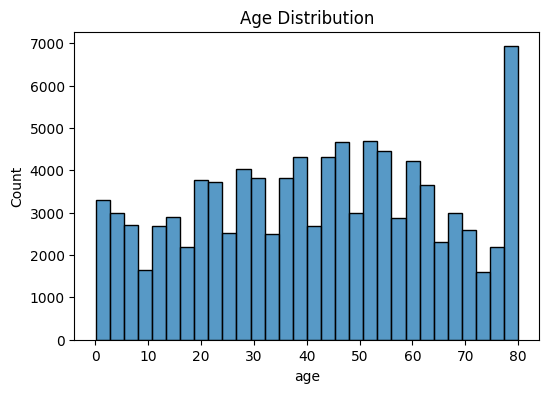

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

## BMI Distribution

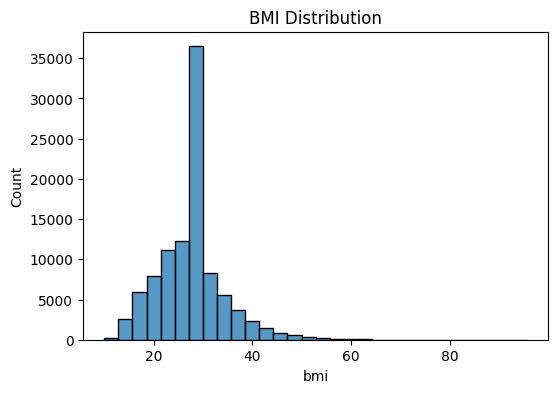

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], bins=30)
plt.title("BMI Distribution")
plt.show()

## Correlation Heatmap (Numerical Only)

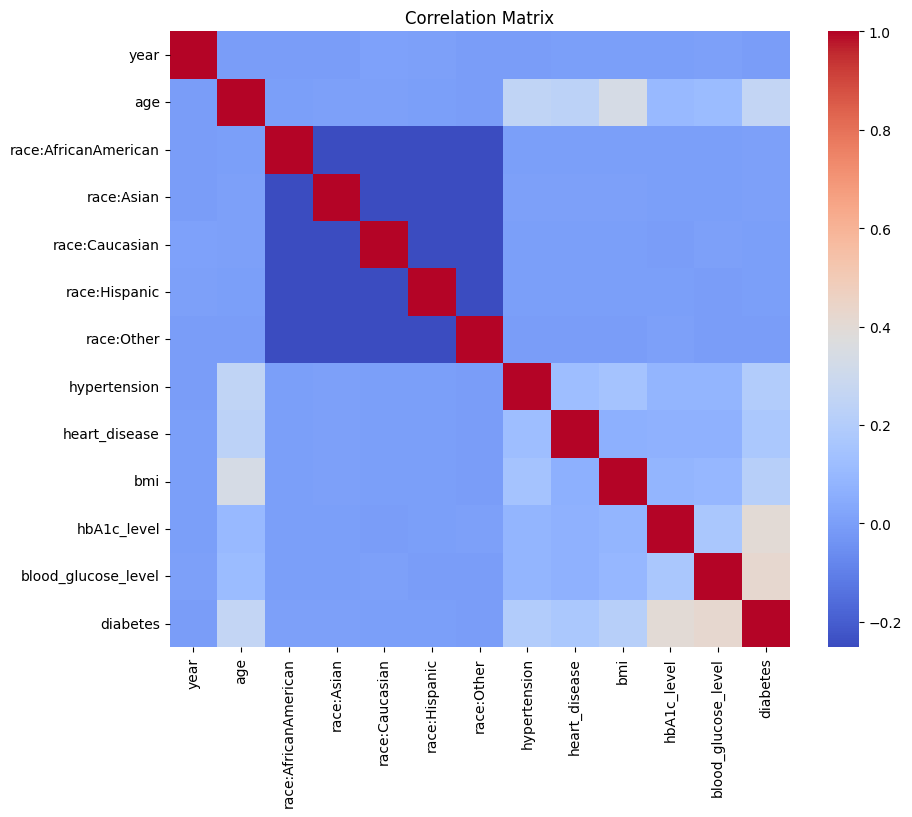

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Compare Numerical Features by Diabetes Status

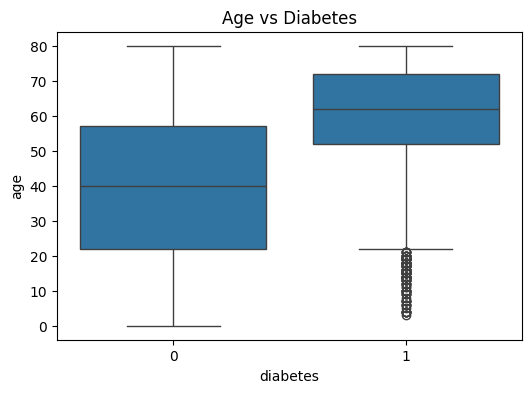

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

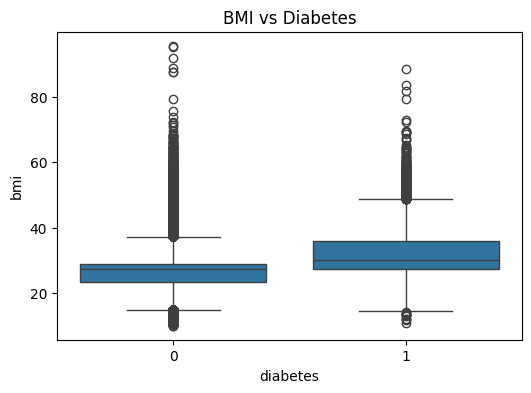

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title("BMI vs Diabetes")
plt.show()

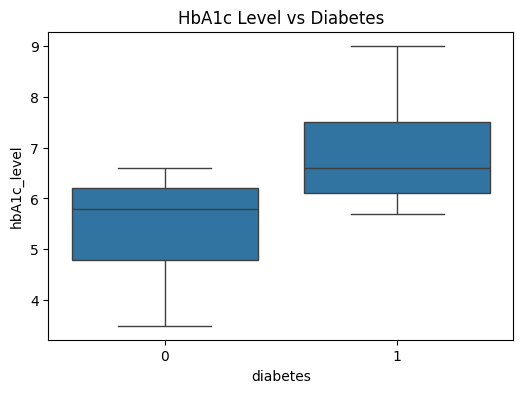

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='hbA1c_level', data=df)
plt.title("HbA1c Level vs Diabetes")
plt.show()

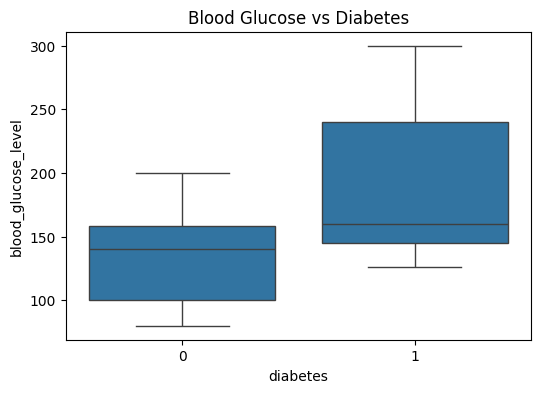

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title("Blood Glucose vs Diabetes")
plt.show()

## Categorical Feature Analysis

In [ ]:
pd.crosstab(df['hypertension'], df['diabetes'], normalize='index')

diabetes,0,1
hypertension,,
0,0.930692,0.069308
1,0.721042,0.278958


In [ ]:
pd.crosstab(df['heart_disease'], df['diabetes'], normalize='index')

diabetes,0,1
heart_disease,,
0,0.924702,0.075298
1,0.678590,0.321410


In [ ]:
pd.crosstab(df['smoking_history'], df['diabetes'], normalize='index')

diabetes,0,1
smoking_history,,
No Info,0.959404,0.040596
current,0.897911,0.102089
ever,0.882118,0.117882
former,0.829983,0.170017
never,0.904659,0.095341
not current,0.892973,0.107027


## Check Class Imbalance Visually

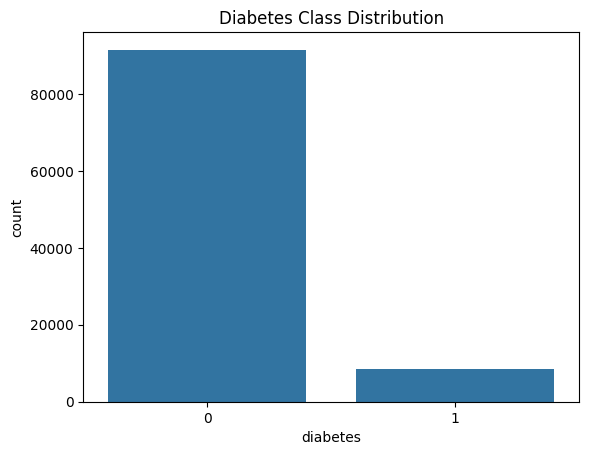

In [ ]:
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Class Distribution")
plt.show()

## Check Outliers

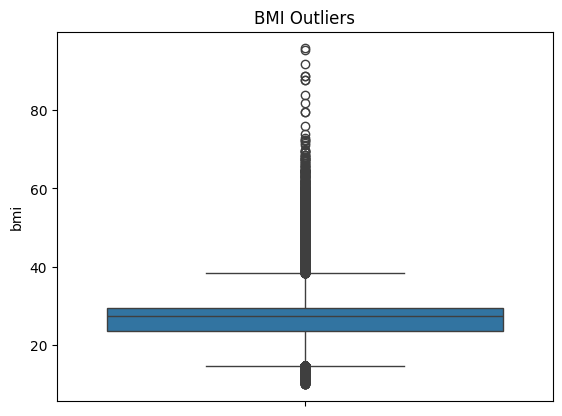

In [ ]:
sns.boxplot(df['bmi'])
plt.title("BMI Outliers")
plt.show()